# SOME OTHER APPROACHES TO MEDICAL PROGNOSIS:

- Attention-based Multimodal Networks
- TabTransformer
- FT-Transformer
- Deep & Cross Network (DCN v2)
- Wide & Deep Networks (Google introduced for recommendation systems)
- Graph Neural Networks (Represent diseases and symptoms as a graph).
- Siamese Networks (Instead of directly predicting the disease, learn an embedding where similar patients are close together.)
- Mixture of Experts (MoE, Instead of one network, train several experts).
- Bayesian Neural Networks (predict probability).
- Contrastive Learning (different symptomps -> far apart).

To not forget: try SHAP values

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../results/medical-output.csv')
display(df.head())

,Patient_ID,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Blood_Pressure_mmHg,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan,symptomps_text,Blood_Pressure_mmHg_lower,Blood_Pressure_mmHg_upper,Body_Temperature_C_scaled,Gender_encoded
0,1,74,Male,Fatigue,Sore throat,Fever,69,39.4,132/91,94,Flu,Moderate,Medication and rest,I've been feeling really off lately. It starte...,91,132,0.866667,1
1,2,66,Female,Sore throat,Fatigue,Cough,95,39.0,174/98,98,Healthy,Mild,Rest and fluids,I've been feeling really unwell lately. It sta...,98,174,0.777778,0
2,3,32,Male,Body ache,Sore throat,Fatigue,77,36.8,136/60,96,Healthy,Mild,Rest and fluids,I've been feeling really unwell lately. It sta...,60,136,0.288889,1
3,4,21,Female,Shortness of breath,Headache,Cough,72,38.9,147/82,99,Healthy,Mild,Rest and fluids,I've been feeling quite unwell lately. It star...,82,147,0.755556,0
4,5,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,109/106,92,Healthy,Mild,Rest and fluids,I've been feeling really unwell lately. It sta...,106,109,0.244444,1


## Bayesian Neural Network

TODO: add nlp!

['Mild' 'Moderate' 'Severe']
Epoch 1/100


c:\personal\sci\nlp-fuzzy\src\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6023 - loss: 0.9078 - val_accuracy: 0.6406 - val_loss: 0.8337
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6695 - loss: 0.7855 - val_accuracy: 0.6281 - val_loss: 0.8013
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6758 - loss: 0.7452 - val_accuracy: 0.6344 - val_loss: 0.7720
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6680 - loss: 0.7233 - val_accuracy: 0.6500 - val_loss: 0.7454
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6703 - loss: 0.6916 - val_accuracy: 0.6344 - val_loss: 0.7172
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6766 - loss: 0.6584 - val_accuracy: 0.6406 - val_loss: 0.7025
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6656 - loss: 0.6643 - val_accuracy: 0.6344 - val_loss: 0.6876
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6766 - loss: 0.6519 - val_accuracy: 0.6344 - val_loss: 0.6

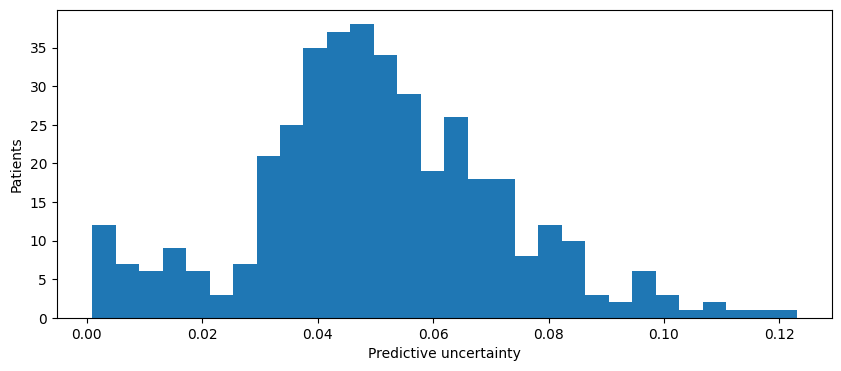

Accepted: 400
Rejected: 0


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = [
    "Age",
    "Gender_encoded",
    "Heart_Rate_bpm",
    "Body_Temperature_C_scaled",
    "Blood_Pressure_mmHg_lower",
    "Blood_Pressure_mmHg_upper",
    "Oxygen_Saturation_%"
]

label_encoder = LabelEncoder()
df["Severity_encoded"] = label_encoder.fit_transform(df["Severity"])
print(label_encoder.classes_)

# SPLIT DATA 
X = df[FEATURES].values
y = df["Severity_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Bayesian Network
import tensorflow as tf
from keras.layers import Dense, Dropout
from keras.models import Sequential

model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(len(FEATURES),)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        3,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# TRAIN
from keras.callbacks import EarlyStopping

es = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es]
)

# Monte-Carlo Prediction
import numpy as np

def predict_mc(model, X, T=100):
    predictions = []

    for _ in range(T):
        p = model(
            X,
            training=True
        ).numpy()

        predictions.append(p)

    predictions = np.array(predictions)
    mean = predictions.mean(axis=0)
    std = predictions.std(axis=0)

    return mean, std

mean_probs, uncertainty = predict_mc(
    model,
    X_test,
    T=100
)

predictions = np.argmax(
    mean_probs,
    axis=1
)

# ACCURACY
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    )
)

print(confusion_matrix(y_test, predictions))

# UNCERTAINTY ESTIMATION
sample_uncertainty = uncertainty.mean(axis=1)

for i in range(10):
    print()
    print("Prediction:",
          label_encoder.inverse_transform([predictions[i]])[0])
    print("Confidence:",
          mean_probs[i].max())
    print("Uncertainty:",
          sample_uncertainty[i])

# PLOT UNCERTAINTY
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(
    sample_uncertainty,
    bins=30
)
plt.xlabel("Predictive uncertainty")
plt.ylabel("Patients")
plt.show()


# WE CAN REJECT UNCERTAIN PREDICTIONS 
threshold = 0.15
accepted = sample_uncertainty < threshold
print(
    "Accepted:",
    accepted.sum()
)
print(
    "Rejected:",
    (~accepted).sum()
)